In [4]:
import sys
sys.path.insert(0, "/Users/ruturajdesai/Desktop/Data-Science/projects/end_to_end/aml_detection")

import pandas as pd
from aml_detection.config import INTERIM_DATA_DIR

# EDA — IBM AML Transaction Data (HI-Small)

All analysis on the **training split only** (first 70% by time). The test set is
untouched until final evaluation, so feature decisions cannot be influenced by
data the model will be scored on.

Terminology in this project:

- Positive(1) = laundering transaction (2,856 in your training split). 

- Negative(0)= normal transaction (~3.55M). 

- Positive rate / base rate = 0.080%. 



Training data: 3.55M rows, 2,856 positives (0.080% — 1 in 1,244).
so lets start spliiting :)


In [7]:
import pandas as pd
from aml_detection.config import INTERIM_DATA_DIR
from aml_detection.eda import (
    overview, target_balance,
    explore_categorical, explore_numeric, explore_boolean, explore_temporal,
)

df = pd.read_parquet(INTERIM_DATA_DIR / "merged" / "transactions_merged.parquet")

# temporal split - EDA on train only
SPLIT = df.timestamp.quantile(0.70)
train = df[df.timestamp <= SPLIT]
test  = df[df.timestamp >  SPLIT]      # do not touch until final evaluation

print(f"train {len(train):,} rows, {train.is_laundering.sum():,} positives")
print(f"test  {len(test):,} rows, {test.is_laundering.sum():,} positives")
print(f"split at {SPLIT}")

train 3,554,066 rows, 2,856 positives
test  1,523,171 rows, 1,666 positives
split at 2022-09-07 14:52:12


In [6]:
train.head()


,timestamp,src_bank,src_account,dst_bank,dst_account,amount_received,currency_received,amount_paid,currency_paid,payment_format,is_laundering,is_self_loop,is_cross_currency,amount_delta,is_burn_in,src_entity_type,src_bank_country,dst_entity_type,dst_bank_country
0,2022-09-01,32282,32282_801B64CE0,32282,32282_801B64CE0,29294.03,US Dollar,29294.03,US Dollar,Reinvestment,0,True,False,0.0,True,Sole Proprietorship,Named,Sole Proprietorship,Named
1,2022-09-01,212818,212818_804B1DF50,212818,212818_804B1DF50,538528.53,Rupee,538528.53,Rupee,Reinvestment,0,True,False,0.0,True,Partnership,India,Partnership,India
2,2022-09-01,16927,16927_8062913A0,28,28_806291440,96718657.00,Ruble,96718657.00,Ruble,ACH,0,False,False,0.0,True,Partnership,Russia,Partnership,Australia
3,2022-09-01,12561,12561_802CF1BB0,18428,18428_8095524B0,2122.85,Euro,2122.85,Euro,Credit Card,0,False,False,0.0,True,Sole Proprietorship,Spain,Partnership,Italy
4,2022-09-01,131086,131086_80CB3F220,131086,131086_80CB3F220,20289185.18,Mexican Peso,20289185.18,Mexican Peso,Reinvestment,0,True,False,0.0,True,Sole Proprietorship,Mexico,Sole Proprietorship,Mexico


2026-08-16 11:16:26.185 | INFO     | aml_detection.eda:target_balance:56 - 2,856 positives in 3,554,066 rows (0.0804%). 1 in 1,244.
2026-08-16 11:16:26.224 | WARNING  | aml_detection.eda:target_balance:61 - Severe imbalance: ROC-AUC will look flattering and mean little. Report PR-AUC and recall at a fixed alert budget instead.


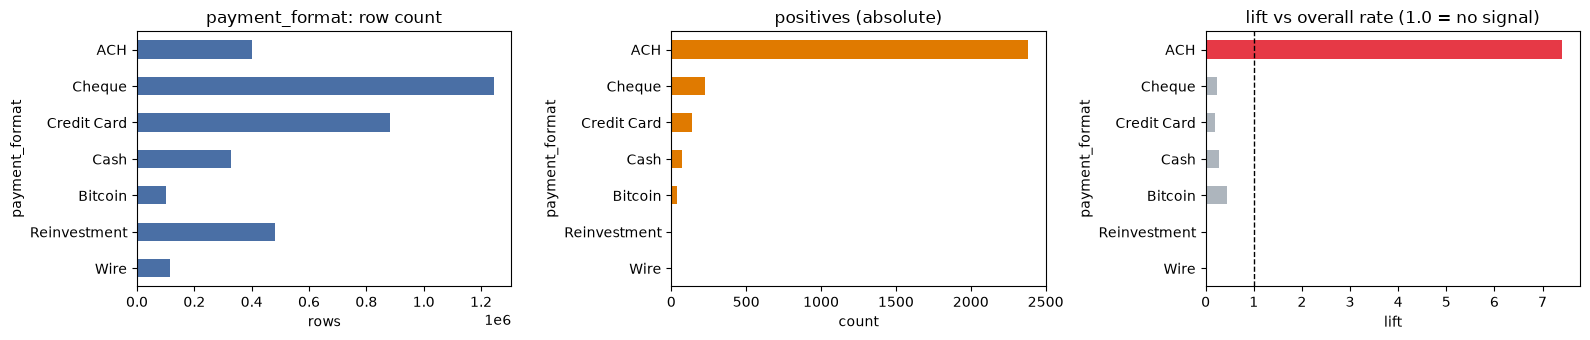

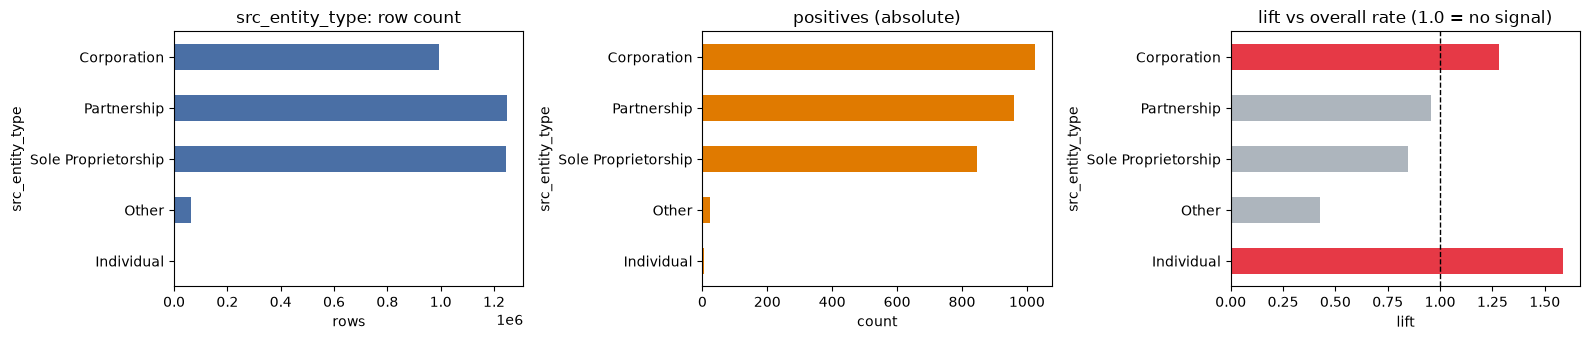

2026-08-16 11:16:27.075 | INFO     | aml_detection.eda:explore_categorical:101 - 5 categories below 500 rows excluded from plot


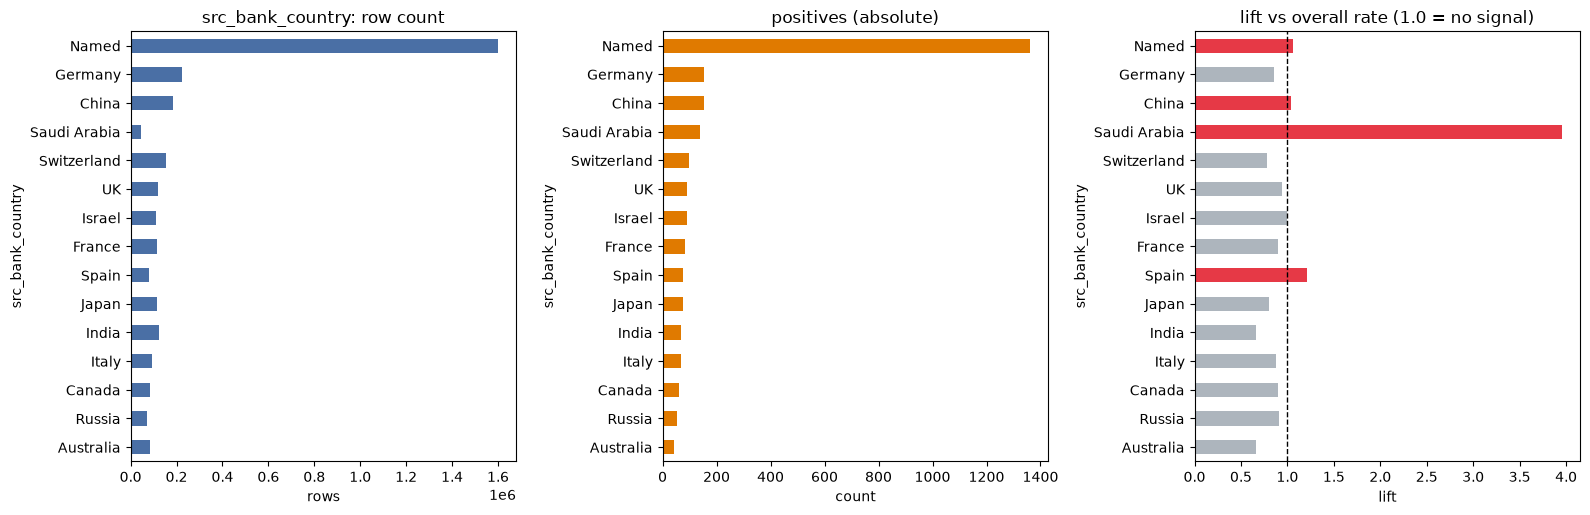

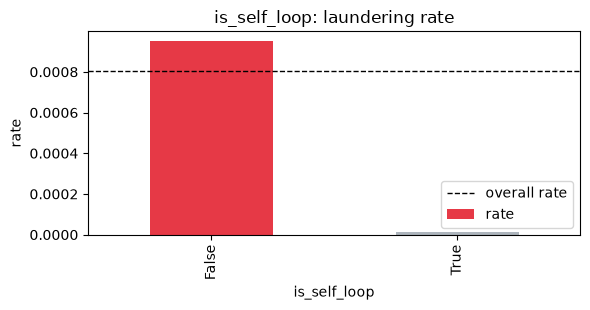

2026-08-16 11:16:27.614 | WARNING  | aml_detection.eda:explore_boolean:227 - is_cross_currency=[True] contains ZERO positives. Either the flag is useless, or those rows can be excluded from training entirely.


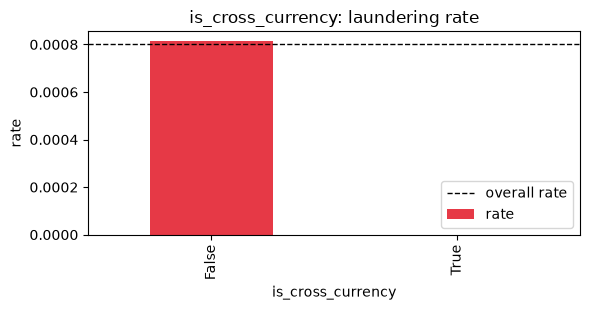

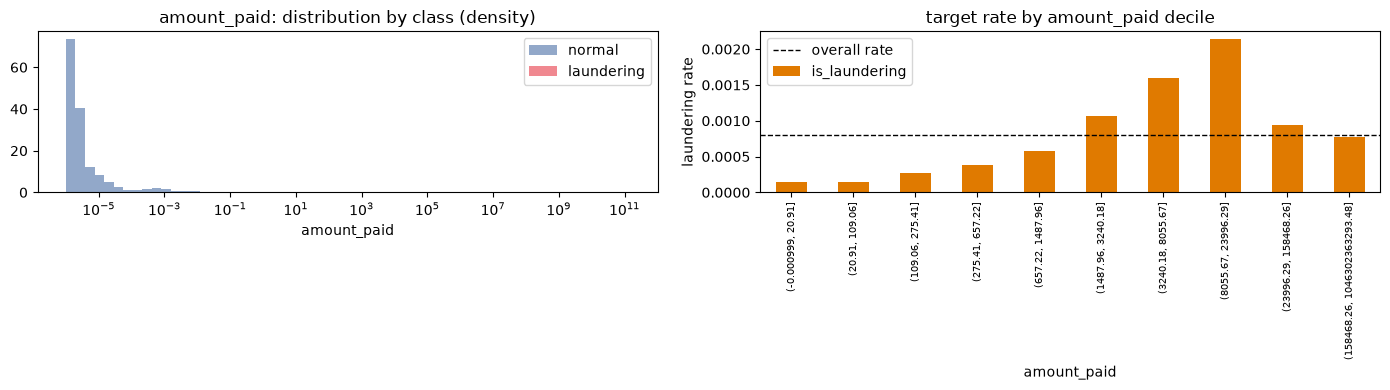

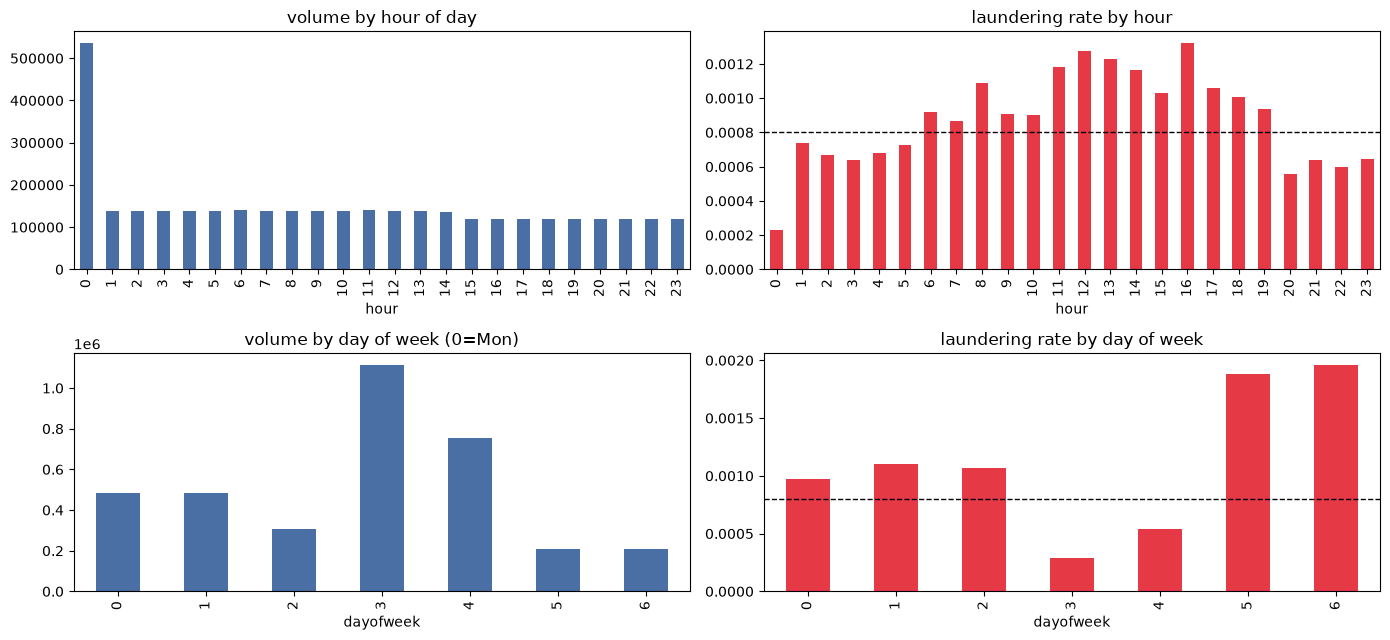

n  positives      rate
unit                                      
hour      0    536869        124  0.000231
          1    139213        103  0.000740
          2    138933         93  0.000669
          3    139198         89  0.000639
          4    138604         94  0.000678
          5    139418        101  0.000724
          6    140234        129  0.000920
          7    139185        121  0.000869
          8    137880        150  0.001088
          9    137915        125  0.000906
          10   138980        125  0.000899
          11   139564        165  0.001182
          12   138471        177  0.001278
          13   138659        170  0.001226
          14   136519        159  0.001165
          15   120461        124  0.001029
          16   119324        158  0.001324
          17   118700        126  0.001061
          18   119054        120  0.001008
          19   119460        112  0.000938
          20   119772         67  0.000559
          21   118887         76  0.000639
          22   118836         71  0.000597
          23   119930         77  0.000642
dayofweek 0    482650        471  0.000976
          1    482089        531  0.001101
          2    305145        326  0.001068
          3   1114921        322  0.000289
          4    754449        408  0.000541
          5    207382        391  0.001885
          6    207430        407  0.001962

In [8]:


# 1. shape of everything
overview(train)

# 2. what are we predicting
target_balance(train)

# 3. column by column
explore_categorical(train, "payment_format")
explore_categorical(train, "src_entity_type")
explore_categorical(train, "src_bank_country")

explore_boolean(train, "is_self_loop")
explore_boolean(train, "is_cross_currency")

explore_numeric(train, "amount_paid")

explore_temporal(train)

# what plots says ?
#### Lets look at this per column mentioned 

## Payment_format

**What the graph shows**

| format | rows | positives | rate | lift |
|---|---|---|---|---|
| ACH | 400K | 2,381 | 0.60% | 7.3× |
| Cheque | 1.24M | 226 | 0.02% | 0.2× |
| Credit Card | 883K | 139 | 0.02% | 0.2× |
| Cash | 328K | 74 | 0.02% | 0.3× |
| Bitcoin | 102K | 36 | 0.04% | 0.4× |
| Reinvestment | 481K | 0 | 0% | 0 |
| Wire | 116K | 0 | 0% | 0 |

ACH holds 83% of all laundering from 11% of rows. Two formats have zero
positives across 597K rows.

**What it means**

Format is the strongest single discriminator found so far. The problem is
closer to "which ACH transactions are suspicious" than "which transactions
are suspicious".

Zero-positive formats cannot teach the model anything about the target — they
are 12% of data contributing no signal.

**Decision**

- Include `payment_format` as a feature.
- Exclude Reinvestment and Wire from training rows (raises positive rate
  0.080% → 0.096% at no cost).
- Keep all formats in the *scoring* path: a production model must score
  everything, and zero-Wire-laundering is a simulator artifact — wires are a
  primary laundering channel in reality.
- Report recall per format at evaluation.

## amount_paid

**What the graph shows**

Currency medians span six orders of magnitude: Bitcoin 0.07, USD 962,
Rupee 69,166, Yen 101,537. The raw histogram is unreadable as a result.

Within US Dollar only:

| percentile | normal | laundering | ratio |
|---|---|---|---|
| 25% | 153 | 1,898 | 12× |
| 50% | 960 | 4,995 | 5× |
| 75% | 6,024 | 12,817 | 2× |
| 95% | 224,277 | 27,523 | 0.12× |

Decile plot: rate climbs from 0.00015 (decile 1) to 0.0021 (decile 8,
~8K–24K), then falls in the top two deciles.

**What it means**

Raw amount is not comparable across rows — the column mixes currencies with
no exchange rates available.

The signal is a **band**, not a magnitude. Laundering is rarely small and
rarely very large. Normal traffic has both a mass of tiny amounts and a long
tail into the millions; laundering has neither. This is consistent with
structuring: large enough to be worth moving, small enough to avoid scrutiny.

A monotonic feature (raw or log amount) would underfit a non-monotonic signal.

**Decision**

- Do not use raw or log `amount_paid`.
- Build **percentile rank within currency** — makes "large for a Rupee
  transaction" comparable to "large for a Dollar transaction" with no FX
  assumptions.
- Also test distance-from-band and round-number proximity as structuring
  indicators.
- Compute percentiles on training data only; apply the fitted boundaries at
  inference to avoid train-serve skew.

## timestamp

**What the graph shows**

- **Hour:** rate peaks 11:00–16:00 (~0.0013), lowest at hour 0 (~0.0002).
  Volume is flat across hours except a spike at hour 0.
- **Day of week:** days 5–6 show the highest rates (~0.0019) but the lowest
  volume (~200K vs 1.1M on day 3).

**What it means**

Hour-of-day is a genuine behavioural pattern and is knowable at scoring time.

Day-of-week is not trustworthy. The file spans 10 days, so each weekday has
only 1–2 observations, and the highest rates coincide with the lowest volumes.
This is a property of which calendar days the simulation covered, not a weekly
banking rhythm.

The hour-0 volume spike is likely a default timestamp for records without a
precise time, not a real 4× surge in activity.

**Decision**

- Build `hour_of_day` as a feature (cyclical encoding: sin/cos).
- Do not build `day_of_week`.
- Never use absolute date or days-since-file-start — those encode position
  within this file and cannot exist in production.
- Flag hour-0 separately so the model can treat it as "time unknown" rather
  than midnight.

## is_cross_currency, amount_delta, is_self_loop : columns

**What the graph shows**

- `is_cross_currency` = True: 47,865 rows, **0 positives**
- `is_self_loop` = True: **0 positives** (mostly Reinvestment, but also 11.8%
  of ACH and 21.6% of Bitcoin)
- `amount_delta` non-zero exactly when currencies differ (1.35% of rows)

**Hypothesis under test**

Domain Knowledge:Cross-currency movement is a recognised layering technique in practice, so the
prior expectation was an *elevated* laundering rate. The observed rate is zero,
which is the opposite direction — worth testing formally rather than reading
off a bar chart.

- H₀: laundering is independent of whether a transaction crosses currencies
- H₁: the two are associated
- Test: **Fisher's exact** (2×2, chosen over chi-square because the expected
  count in the positive/cross-currency cell is small)
- α = 0.01

Under independence, 47,865 cross-currency rows would be expected to contain
~38 positives at the 0.080% base rate.

In [9]:
from scipy.stats import chi2_contingency, fisher_exact

table = pd.crosstab(train.is_cross_currency, train.is_laundering)

chi2, p_chi, dof, expected = chi2_contingency(table)
odds, p_fisher = fisher_exact(table)

print("expected counts under H0:\n", expected.round(1))
print(f"\nchi-square : chi2={chi2:.2f}, p={p_chi:.3e}")
print(f"fisher     : OR={odds:.4f}, p={p_fisher:.3e}")

expected counts under H0:
 [[3.5033835e+06 2.8175000e+03]
 [4.7826500e+04 3.8500000e+01]]

chi-square : chi2=38.01, p=7.030e-10
fisher     : OR=0.0000, p=3.473e-17


**Result**

|  | expected under H₀ | observed |
|---|---|---|
| cross-currency, laundering | 38.5 | **0** |

- Chi-square: χ² = 38.01, p = 7.03 × 10⁻¹⁰
- Fisher's exact: OR = 0.0000, p = 3.47 × 10⁻¹⁷

H₀ rejected at α = 0.01 by both tests. The odds ratio of exactly zero reflects
the empty cell — no laundering transaction in the training data crosses
currencies.

**Interpretation**

The association is real, not sampling noise. But significance establishes only
that the pattern is unlikely under independence — it does not make the feature
useful.

Two reasons to reject it despite significance:

1. **Direction contradicts domain knowledge.** Cross-currency movement is a
   recognised layering technique; a protective effect is not plausible
   behaviour.
2. **A perfectly empty cell across 47,865 rows** is characteristic of a
   generator constraint, not a behavioural tendency. Real data would show
   *some* overlap.

A model trained on this would learn "cross-currency ⇒ safe" and would fail on
any data where that constraint does not hold.

**Decision**

Drop `is_cross_currency` and `amount_delta`. Exclude self-loop rows from
training rather than retaining the flag.

#### now we know that there are some features which can be used but we can engineer many more features with temporal data like averages cureencies 

In [12]:
# let us first try to normalise amount. This is achieved  by trying two methods 

import numpy as np

# ---- amount, normalised within currency ----------------------------------
# Raw amount is not comparable across rows: currency medians span six orders
# of magnitude (Bitcoin 0.07 -> Yen 101,537). Two complementary normalisations:
#   pct  - robust to outliers, captures "large for this currency"
#   logz - keeps magnitude information that rank discards; log first because
#          raw z-score is dominated by a 10^12 tail
g_amt = train.groupby("currency_paid", observed=True).amount_paid

train = train.assign(
    amt_pct_ccy=g_amt.rank(pct=True),
    log_amount=lambda d: np.log1p(d.amount_paid),
)
g_log = train.groupby("currency_paid", observed=True).log_amount
train = train.assign(
    amt_logz_ccy=lambda d: (d.log_amount - g_log.transform("mean"))
                            / g_log.transform("std"),
)

# ---- time -----------------------------------------------------------------
# Cyclical encoding so hour 23 and hour 0 are adjacent, not maximally distant.
train = train.assign(
    hour=lambda d: d.timestamp.dt.hour,
    hour_sin=lambda d: np.sin(2 * np.pi * d.hour / 24),
    hour_cos=lambda d: np.cos(2 * np.pi * d.hour / 24),
    is_hour_zero=lambda d: d.hour == 0,     # likely "time unknown", not midnight
)

In [13]:
CCY_STATS = (
    train.groupby("currency_paid", observed=True)
         .log_amount.agg(["mean", "std"])
)

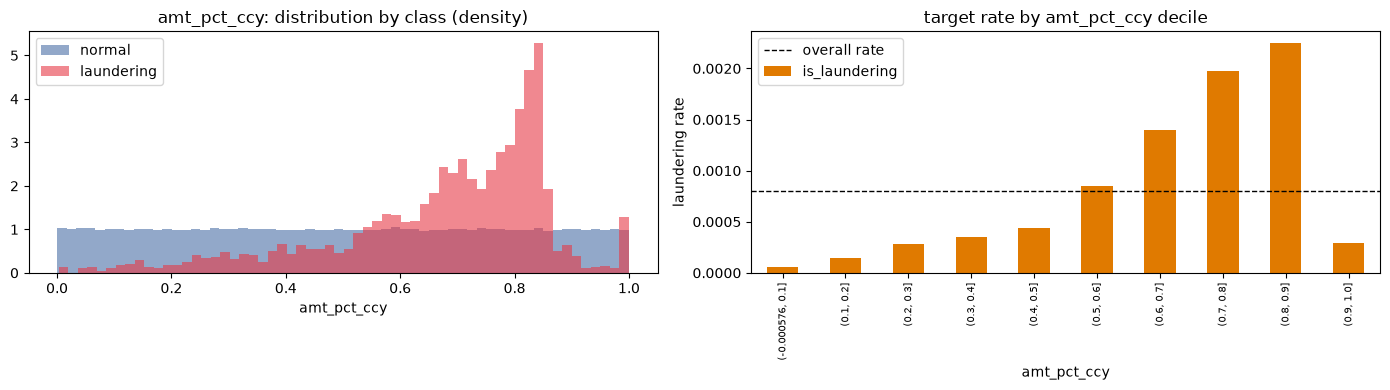

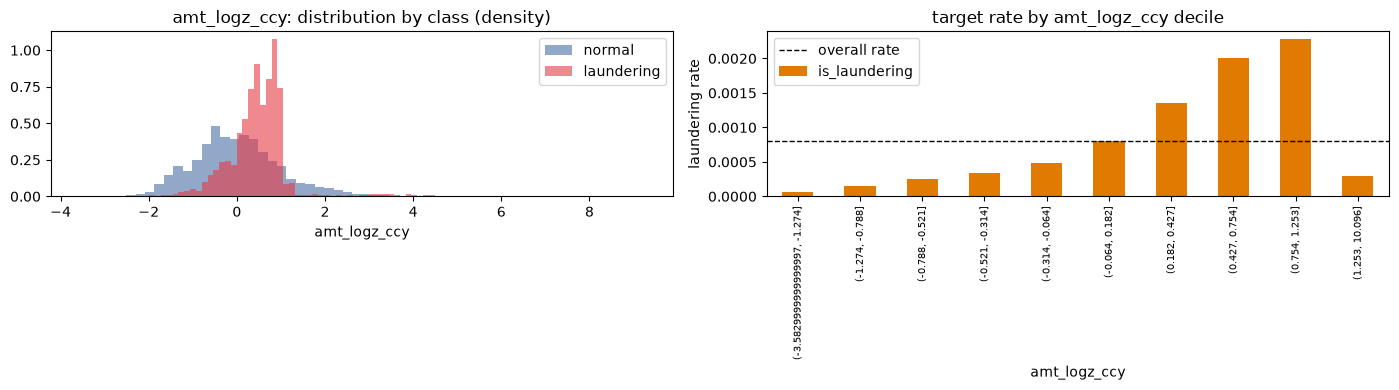

is_laundering,0,1
count,3.551210e+06,2856.000000
mean,-3.872635e-04,0.481532
std,1.000111e+00,0.697342
min,-3.581627e+00,-2.251844
25%,-6.448989e-01,0.159073
50%,-6.465909e-02,0.500413
75%,5.677812e-01,0.832204
95%,1.811841e+00,1.082152
99%,2.779553e+00,3.371894
max,1.009617e+01,5.679550


In [14]:
from aml_detection.eda import explore_numeric
explore_numeric(train, "amt_pct_ccy", log_scale=False)
explore_numeric(train, "amt_logz_ccy", log_scale=False)

In [15]:
print(train[["amt_pct_ccy", "amt_logz_ccy"]].corr().round(3))

              amt_pct_ccy  amt_logz_ccy
amt_pct_ccy         1.000         0.955
amt_logz_ccy        0.955         1.000


## Engineered: amount normalised within currency

**Why raw amount could not be used**

Currency medians span six orders of magnitude (Bitcoin 0.07, USD 962,
Rupee 69,166, Yen 101,537) and no exchange rates are available. Two rows with
the same value can mean completely different things.

Two candidates were built and compared:

- `amt_pct_ccy` — percentile rank within currency
- `amt_logz_ccy` — log transform, then z-score within currency

A plain z-score on raw amounts was rejected: with a maximum of 10¹², mean and
standard deviation are dominated by outliers and almost every row collapses
into a narrow band near zero.

**What the graphs show**

Class separation is visible for the first time. Normal transactions are
uniform across `amt_pct_ccy` by construction, so any departure from flat is
the signal — laundering concentrates sharply between 0.6 and 0.85, peaking
near 0.8.

Both features produce near-identical decile curves:

| decile | laundering rate |
|---|---|
| 1 (smallest) | 0.00005 |
| 5 | 0.00085 |
| 9 | 0.0022 ← peak |
| 10 (largest) | 0.0003 ← collapse |

The rate rises steadily, peaks at decile 9, then **falls by a factor of seven
in the top decile**.

**What it means**

The relationship is non-monotonic. Laundering occupies a band — rarely small,
rarely very large. This is consistent with structuring: amounts large enough
to be worth moving, small enough to avoid the scrutiny that the largest
transactions attract.

A monotonic model (logistic regression on raw amount) would underfit this.
Tree-based models handle it natively, which is an argument for XGBoost over a
linear baseline here.

**Redundancy check**

`amt_pct_ccy` and `amt_logz_ccy` correlate at **0.955** — they measure the
same thing. Only one is kept.

**Decision**

- **Keep `amt_pct_ccy`.** Bounded 0–1, robust to outliers, and requires no
  fitted mean/std to persist — one less object to version and one less source
  of train-serve skew.
- **Drop `amt_logz_ccy` and `log_amount`** as redundant.
- **Retain raw `amount_paid`** at no cost; tree models may still find useful
  splits.
- **Test `amt_in_band`** (percentile between 0.55 and 0.90) as a compact,
  explainable encoding of the structuring pattern.

Note: percentile boundaries are fitted on training data and must be reused at
inference rather than recomputed on incoming batches.

In [16]:
def build_account_features(df: pd.DataFrame) -> pd.DataFrame:
    """Account-level history features using ONLY prior transactions.

    Every feature answers: what did the bank know about this account
    immediately BEFORE this transaction?
    """
    df = df.sort_values("timestamp").reset_index(drop=True)
    src = df.groupby("src_account", sort=False)
    dst = df.groupby("dst_account", sort=False)

    out = {}

    # --- volume / velocity (sender) ---
    out["src_txn_count_prior"] = src.cumcount()

    # prior mean = (cumsum - current) / prior_count
    cum_sum = src.amount_paid.cumsum() - df.amount_paid
    out["src_amount_mean_prior"] = cum_sum / out["src_txn_count_prior"].replace(0, np.nan)
    out["src_amount_sum_prior"] = cum_sum

    # deviation from the account's own baseline
    out["src_amount_vs_own_mean"] = df.amount_paid / out["src_amount_mean_prior"]

    # --- timing ---
    out["src_secs_since_last"] = src.timestamp.diff().dt.total_seconds()
    out["dst_secs_since_last"] = dst.timestamp.diff().dt.total_seconds()

    # --- counterparty breadth (vectorised expanding nunique) ---
    # mark the first time each (src,dst) pair appears, then a running count of
    # those firsts within the sender gives distinct counterparties so far
    first_pair = ~df.duplicated(["src_account", "dst_account"])
    running = first_pair.groupby(df.src_account, sort=False).cumsum()
    out["src_unique_dst_prior"] = running - first_pair.astype(int)

    first_pair_in = ~df.duplicated(["dst_account", "src_account"])
    running_in = first_pair_in.groupby(df.dst_account, sort=False).cumsum()
    out["dst_unique_src_prior"] = running_in - first_pair_in.astype(int)

    # --- fan ratios: many counterparties relative to activity ---
    out["src_fanout_ratio"] = (
        out["src_unique_dst_prior"] / out["src_txn_count_prior"].replace(0, np.nan)
    )
    dst_count_prior = dst.cumcount()
    out["dst_txn_count_prior"] = dst_count_prior
    out["dst_fanin_ratio"] = (
        out["dst_unique_src_prior"] / dst_count_prior.replace(0, np.nan)
    )

    out["src_is_new"] = out["src_txn_count_prior"] == 0
    out["dst_is_new"] = dst_count_prior == 0

    return df.assign(**out)

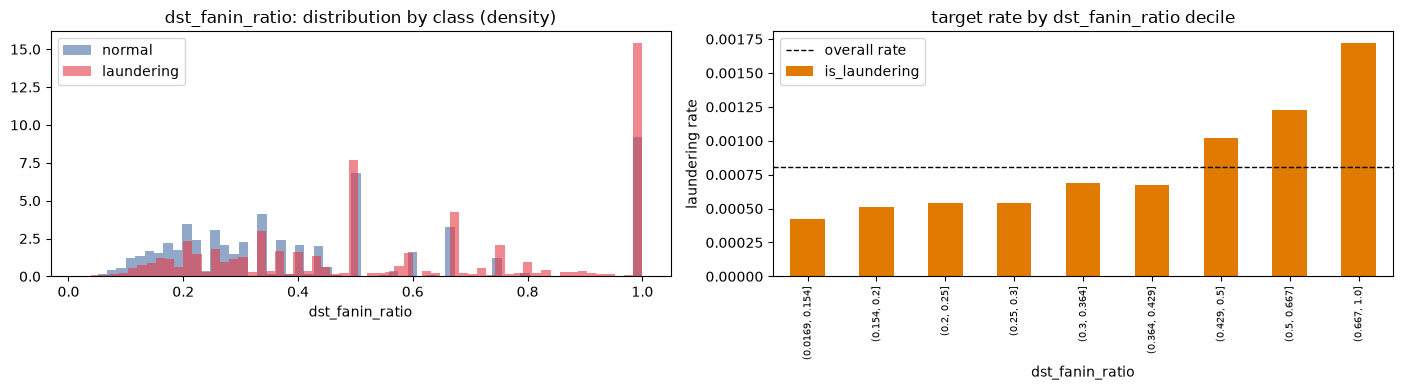

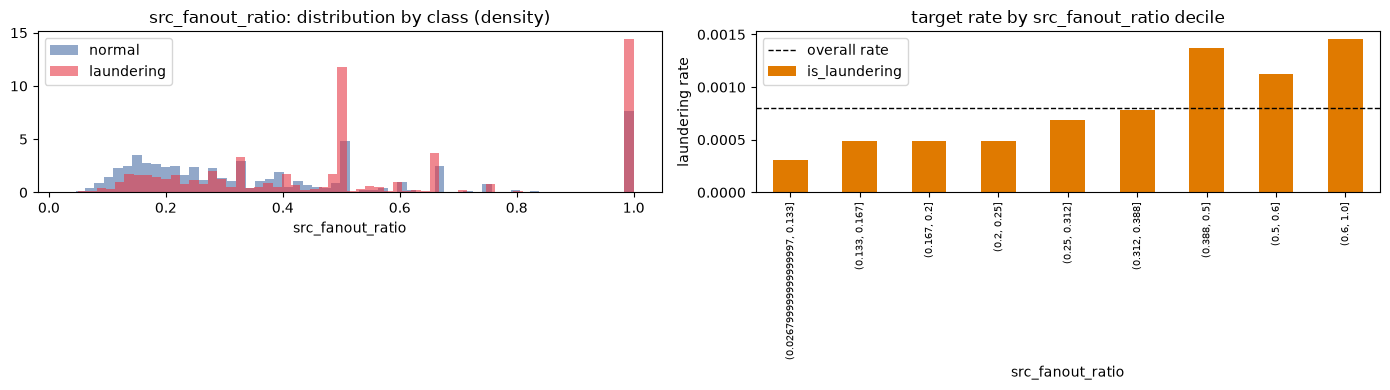

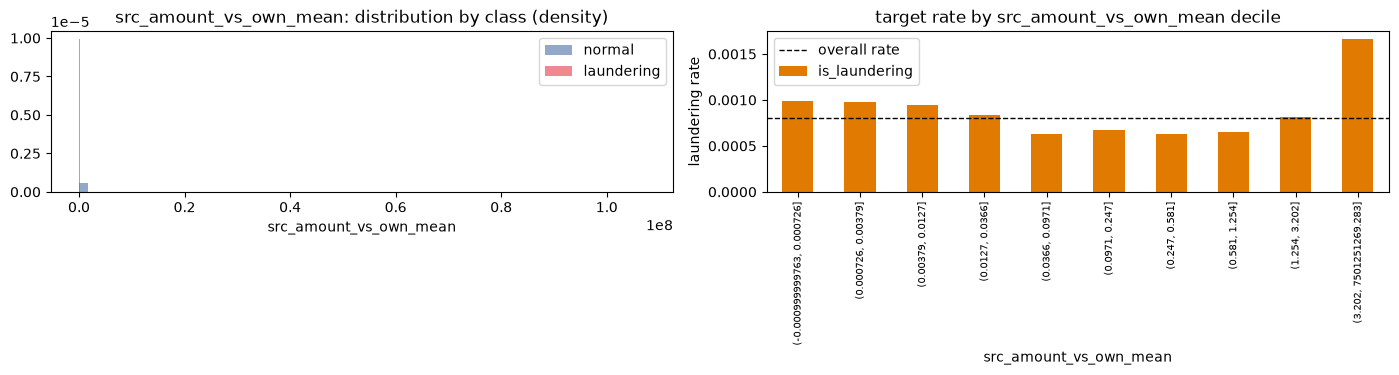

In [19]:
train = build_account_features(train)
for c in ["dst_fanin_ratio", "src_fanout_ratio", "src_amount_vs_own_mean"]:
    explore_numeric(train, c, log_scale=False)

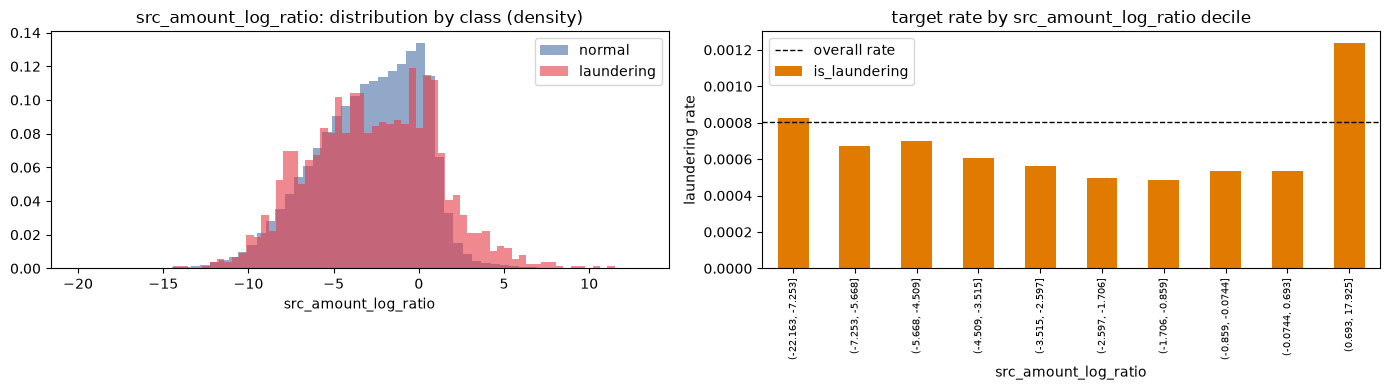

is_laundering,0,1
count,2.627937e+06,1753.000000
mean,-2.931328e+00,-2.676074
std,3.156341e+00,3.716399
min,-2.216161e+01,-14.439737
25%,-5.054237e+00,-5.376846
50%,-2.597350e+00,-2.680808
75%,-4.599139e-01,0.139853
95%,1.287290e+00,3.163965
99%,3.075746e+00,6.088649
max,1.792497e+01,11.503704


In [20]:
train["src_amount_log_ratio"] = np.where(
    train.src_txn_count_prior >= 3,
    np.log(train.amount_paid / train.src_amount_mean_prior),
    np.nan,
)
explore_numeric(train, "src_amount_log_ratio", log_scale=False)

In [21]:
train["src_amount_abs_dev"] = train.src_amount_log_ratio.abs()

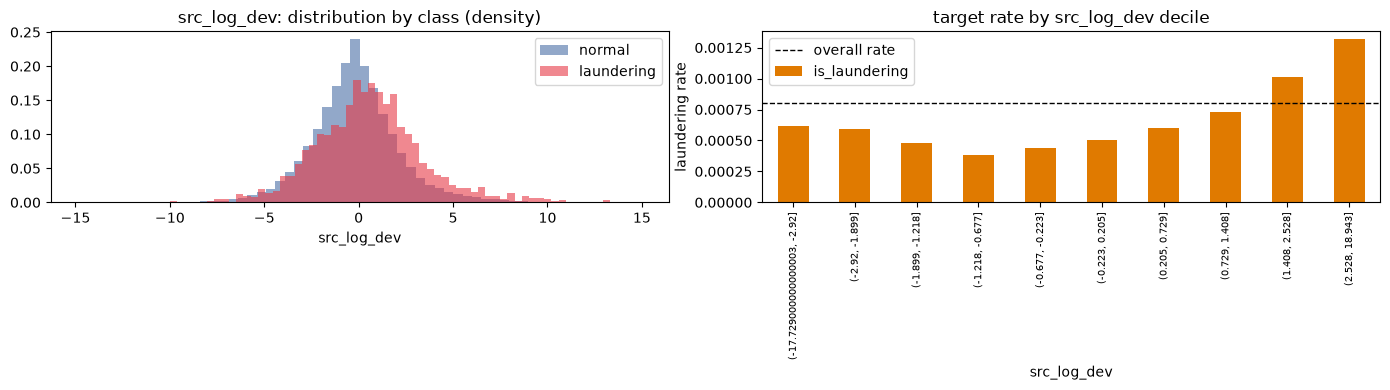

is_laundering,0,1
count,2.627937e+06,1753.000000
mean,-1.856262e-01,0.564110
std,2.325265e+00,2.815421
min,-1.772789e+01,-9.995856
25%,-1.534857e+00,-1.233881
50%,-2.234640e-01,0.498056
75%,1.037960e+00,2.091300
95%,3.739769e+00,5.499207
99%,6.560804e+00,8.967542
max,1.894305e+01,13.317856


In [22]:
# prior median is expensive; a cheap proxy is the log-mean
train["src_log_amount"] = np.log1p(train.amount_paid)
g = train.groupby("src_account", sort=False)
cum = g.src_log_amount.cumsum() - train.src_log_amount
prior_logmean = cum / train.src_txn_count_prior.replace(0, np.nan)

train["src_log_dev"] = np.where(
    train.src_txn_count_prior >= 3,
    train.src_log_amount - prior_logmean,
    np.nan,
)
explore_numeric(train, "src_log_dev", log_scale=False)

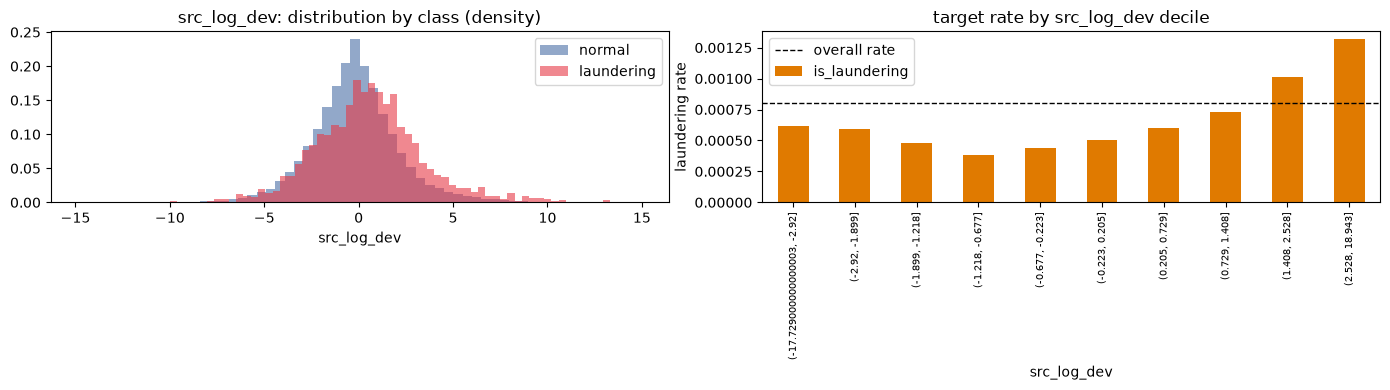

is_laundering,0,1
count,2.627937e+06,1753.000000
mean,-1.856262e-01,0.564110
std,2.325265e+00,2.815421
min,-1.772789e+01,-9.995856
25%,-1.534857e+00,-1.233881
50%,-2.234640e-01,0.498056
75%,1.037960e+00,2.091300
95%,3.739769e+00,5.499207
99%,6.560804e+00,8.967542
max,1.894305e+01,13.317856


In [23]:
# prior median is expensive; a cheap proxy is the log-mean
train["src_log_amount"] = np.log1p(train.amount_paid)
g = train.groupby("src_account", sort=False)
cum = g.src_log_amount.cumsum() - train.src_log_amount
prior_logmean = cum / train.src_txn_count_prior.replace(0, np.nan)

train["src_log_dev"] = np.where(
    train.src_txn_count_prior >= 3,
    train.src_log_amount - prior_logmean,
    np.nan,
)
explore_numeric(train, "src_log_dev", log_scale=False)

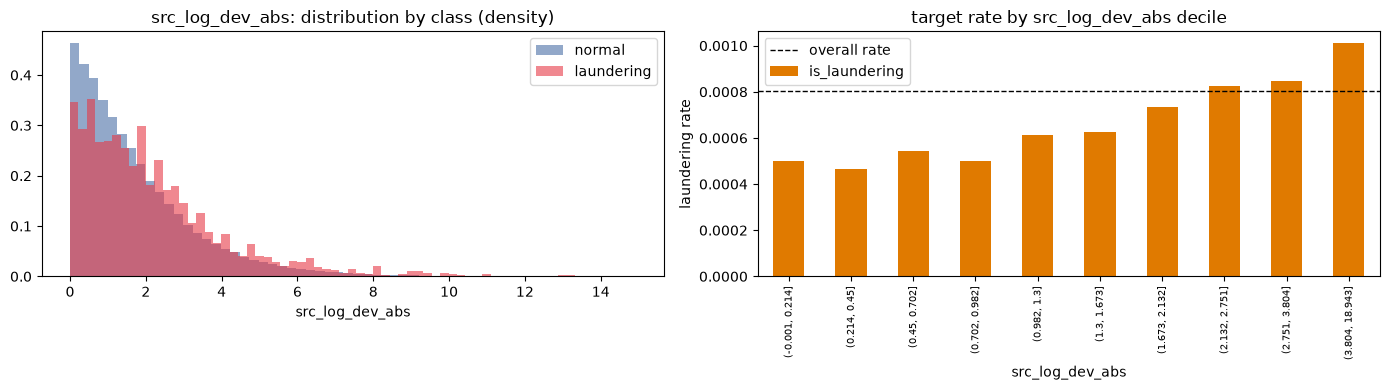

is_laundering,0,1
count,2.627937e+06,1753.000000
mean,1.726995e+00,2.165365
std,1.568057e+00,1.885077
min,0.000000e+00,0.000231
25%,5.720043e-01,0.799154
50%,1.299597e+00,1.741429
75%,2.411780e+00,2.933541
95%,4.854212e+00,6.004009
99%,7.161391e+00,9.000279
max,1.894305e+01,13.317856


In [24]:
train["src_log_dev_abs"] = train.src_log_dev.abs()
explore_numeric(train, "src_log_dev_abs", log_scale=False)

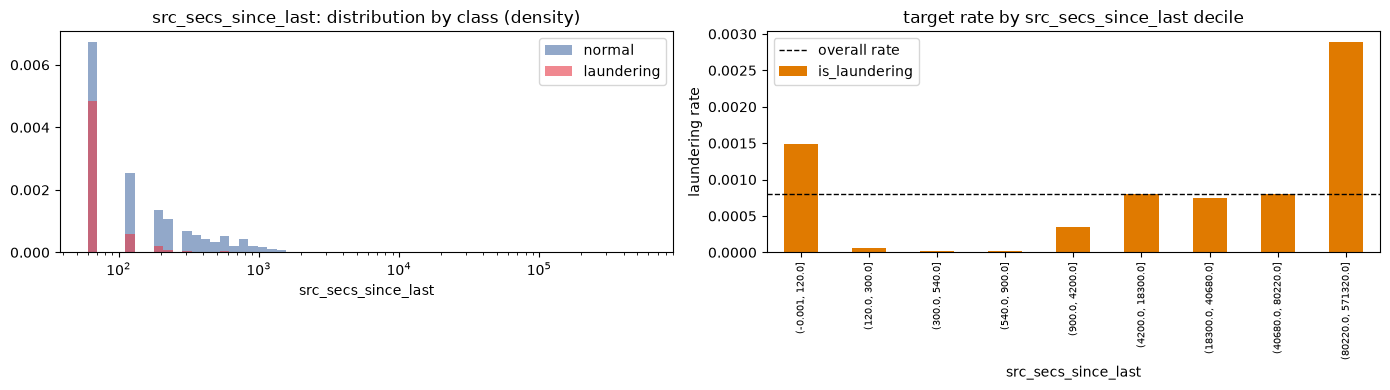

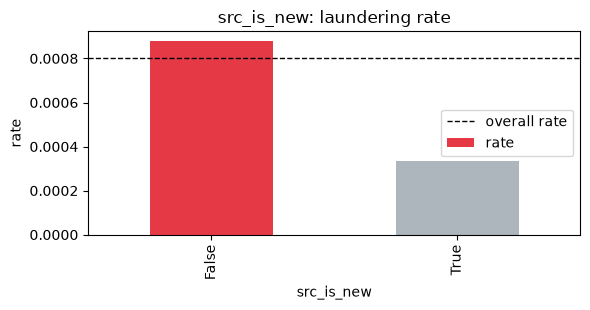

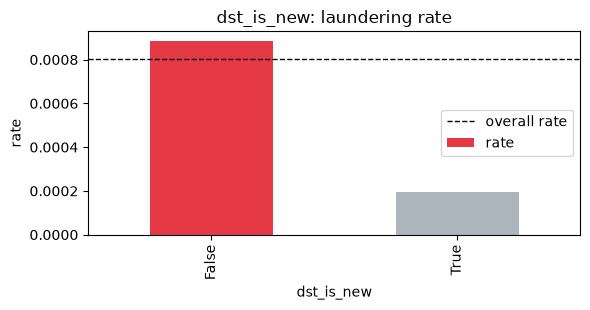

,n,positives,rate,lift
dst_is_new,,,,
False,3134147,2774,0.000885,1.101424
True,419919,82,0.000195,0.243005


In [25]:
explore_numeric(train, "src_secs_since_last", log_scale=True)
explore_boolean(train, "src_is_new")
explore_boolean(train, "dst_is_new")